# Model Analysis

## Overview
This notebook provides an analysis and comparison of different frameworks, hyperparameter tuning and data saturation for PACE compressive sensing. 

## Analysis Components

### 1. Model Performance Comparison (PCA vs NN Family)
- Compares reconstruction quality across different model architectures
- Evaluates validation loss, test loss, and feature-specific error metrics
- Analyzes performance on critical wavelength ranges (630-650nm)
- Assesses which models require meta-optics for implementation

### 2. Hyperparameter Tuning Analysis
- Reviews results from systematic hyperparameter optimization experiments
- Compares different architectural configurations (symmetric vs asymmetric)
- Analyzes the impact of hidden layer sizes and compression ratios
- Identifies optimal configurations for CAE and FSAE models

### 3. Data Saturation Analysis
- Examines how model performance scales with training data size
- Analyzes learning curves across different sample sizes (10% to 100%)

## Key Metrics
- **Reconstruction Quality**: Validation and test loss measurements
- **Feature-Level Performance**: 95th percentile reconstruction errors
- **Critical Wavelength Analysis**: Specialized metrics for 630-650nm range
- **Pixel-Level Performance**: Per-sample reconstruction quality assessment

## Data Sources
The analysis draws from multiple S3 buckets containing:
- Baseline model results (PCA and initial autoencoder experiments)
- Hyperparameter tuning experiment results
- Data saturation study results with various training set sizes

# 0. Insallations and Imports

In [ ]:
import os
import re
import boto3

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from matplotlib import pyplot as plt

load_dotenv()

True

In [ ]:
bucket = os.getenv("BUCKET_NAME")
results_bucket = os.getenv("RESULTS_BUCKET_NAME")
hyperparameters_bucket = os.getenv("HYPERPARAMETERS_RESULTS_BUCKET_NAME")
saturation_results_bucket = os.getenv("SATURATION_BUCKET_NAME")


# 1. Compare results (PCA VS. AE Family)

In [ ]:
s3 = boto3.client("s3")
response = s3.list_objects_v2(Bucket=results_bucket)
paths = {}

for obj in response.get("Contents", []):
    key = obj["Key"]
    match = re.match(r"([^/]+)/v(\d+)/score\.parquet$", key)
    if match:
        model, version = match.groups()
        version = int(version)
        if model not in paths or version > paths[model][0]:
            paths[model] = (version, key)

dfs = []
for model, (version, key) in paths.items():
    score_path = f"s3://{bucket}/{model}/v{version}/score.parquet"

    df = pd.read_parquet(score_path).T
    df.index = [f"{model}_v{version}"]
    dfs.append(df)

combined_scores = pd.concat(dfs)
combined_scores.sort_values(by="test_loss", inplace=True)
combined_scores.insert(0, "requiring metaoptics", [False,True,False,True,True,False,True,True])

combined_scores

,requiring metaoptics,val_loss,test_loss,features_95_percentile,pixel_95_percentile,critical_wavelength_99_percentile
fsae64_v1,False,0.000200,0.000197,0.000629,0.000697,0.000078
pca_v1,True,0.000200,0.000205,0.000948,0.000736,0.000169
fsae_v2,False,0.000221,0.000217,0.000683,0.000844,0.000194
rpca_v1,True,0.000422,0.000417,0.001293,0.001567,0.000599
auto-encoder_v1,True,0.000835,0.001220,0.005572,0.000073,0.000284
concrete-auto-encoder_v1,False,0.000897,0.001281,0.005744,0.000347,0.000276
ica_v1,True,0.002689,0.002696,0.007591,0.003381,0.001601
cppca_v1,True,0.022351,0.015653,0.056901,0.039989,0.060906


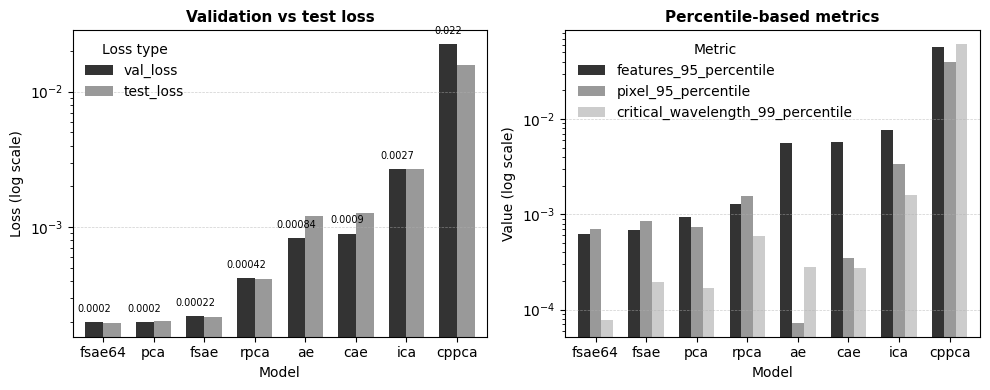

In [ ]:
loss_cols = ["val_loss", "test_loss"]
percentile_cols = [
    "features_95_percentile",
    "pixel_95_percentile",
    "critical_wavelength_99_percentile",
]

def make_clean_labels(index):
    labels = pd.Series(index, index=index).str.split("_", n=1).str[0]
    labels = labels.str.replace("concrete-auto-encoder", "cae", regex=False)
    labels = labels.str.replace("auto-encoder", "ae", regex=False)
    return labels

clean_labels = make_clean_labels(combined_scores.index)

df_loss = combined_scores[loss_cols].copy()

df_loss = df_loss.clip(lower=1e-8)

df_loss["__sort__"] = df_loss.mean(axis=1)
df_loss = df_loss.sort_values("__sort__", ascending=True).drop(columns="__sort__")

loss_labels = clean_labels.reindex(df_loss.index)

df_pct = combined_scores[percentile_cols].copy()
df_pct = df_pct.clip(lower=1e-8)  # again, for log scale

df_pct["__sort__"] = df_pct.mean(axis=1)
df_pct = df_pct.sort_values("__sort__", ascending=True).drop(columns="__sort__")

pct_labels = clean_labels.reindex(df_pct.index)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_loss.plot(
    kind="bar",
    ax=axes[0],
    color=["0.2", "0.6"], 
    logy=True,
    width=0.7,
)

axes[0].set_title("Validation vs test loss", fontsize=11, weight="bold")
axes[0].set_ylabel("Loss (log scale)")
axes[0].set_xlabel("Model")

axes[0].set_xticks(np.arange(len(loss_labels)))
axes[0].set_xticklabels(loss_labels, rotation=0, ha="center")

axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
axes[0].legend(title="Loss type", frameon=False)

loss_col_order = list(df_loss.columns) 
val_idx = loss_col_order.index("val_loss")
val_container = axes[0].containers[val_idx]

for patch, val in zip(val_container.patches, df_loss["val_loss"].values):
    if val <= 0:
        continue
    y = val * 1.15  
    axes[0].text(
        patch.get_x() + patch.get_width() / 2.0,
        y,
        f"{val:.2g}",  
        ha="center",
        va="bottom",
        fontsize=7,
        clip_on=False,
    )

df_pct.plot(
    kind="bar",
    ax=axes[1],
    color=["0.2", "0.6", "0.8"],
    logy=True,
    width=0.7,
)

axes[1].set_title("Percentile-based metrics", fontsize=11, weight="bold")
axes[1].set_ylabel("Value (log scale)")
axes[1].set_xlabel("Model")

axes[1].set_xticks(np.arange(len(pct_labels)))
axes[1].set_xticklabels(pct_labels, rotation=0, ha="center")

axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
axes[1].legend(title="Metric", frameon=False)

plt.tight_layout()
plt.show()


# 2. Compare Results - Hyperparameters Tuning

In [ ]:
s3 = boto3.client("s3")

response = s3.list_objects_v2(Bucket=hyperparameters_bucket)
paths = {}

for obj in response.get("Contents", []):
    key = obj["Key"]
    match = re.match(r"([^/]+)/([^/]+)/(\d+)/v(\d+)/score\.parquet$", key)
    if match:
      model, architecture, neurons, version = match.groups()
      version = int(version)
      model_key = f"{model}/{architecture}/{neurons}"
      if model_key not in paths or version > paths[model_key][0]:
          paths[model_key] = (version, key)

dfs = []
for model_key, (version, key) in paths.items():
    score_path = f"s3://{hyperparameters_bucket}/{model_key}/v{version}/score.parquet"

    df = pd.read_parquet(score_path).T
    index_name = model_key.replace("concrete-auto-encoder", "cae").replace("_architecture","")
    df.index = [f"{index_name}_v{version}"]
    dfs.append(df)

hyperparameter_scores = pd.concat(dfs)
hyperparameter_scores

,layers,symmetric_architecture,val_loss,test_loss,features_95_percentile,pixel_95_percentile,critical_wavelength_99_percentile
cae/asymmetric/16_v1,16.0,0.0,0.001142,0.001523,0.006213,0.001324,0.000472
cae/asymmetric/24_v2,24.0,0.0,0.001036,0.001418,0.006139,0.000866,0.000390
cae/asymmetric/32_v4,32.0,0.0,0.000879,0.001264,0.005595,0.000307,0.000273
cae/asymmetric/48_v2,48.0,0.0,0.000874,0.001260,0.005581,0.000276,0.000273
cae/asymmetric/64_v2,64.0,0.0,0.000881,0.001266,0.005594,0.000303,0.000279
cae/symmetric/16_v1,16.0,1.0,0.002018,0.002401,0.007292,0.002725,0.001762
cae/symmetric/24_v1,24.0,1.0,0.001948,0.002332,0.006804,0.002366,0.001505
cae/symmetric/32_v3,32.0,1.0,0.001622,0.002006,0.005986,0.002072,0.001062
cae/symmetric/48_v1,48.0,1.0,0.001592,0.001976,0.005963,0.002039,0.001048
cae/symmetric/64_v2,64.0,1.0,0.001604,0.001988,0.006062,0.002069,0.001053


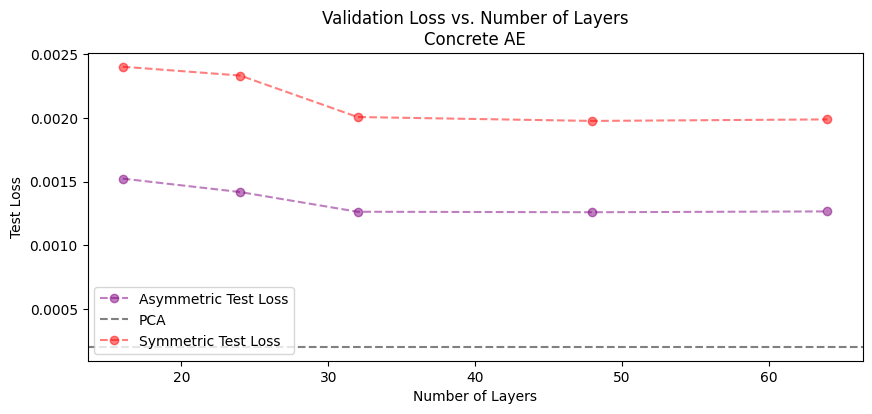

In [ ]:
cae_asymmetric = hyperparameter_scores[hyperparameter_scores.index.str.contains("cae/asymmetric")]
cae_symmetric = hyperparameter_scores[hyperparameter_scores.index.str.contains("cae/symmetric")]

plt.figure(figsize=(10, 4))

plt.plot(cae_asymmetric['layers'], cae_asymmetric['test_loss'], label='Asymmetric Test Loss', linestyle='--', marker='o', color='purple',alpha=0.5)

plt.axhline(y=combined_scores.loc['pca_v1']['test_loss'], color='gray', linestyle='--', label='PCA')

plt.plot(cae_symmetric['layers'], cae_symmetric['test_loss'], label='Symmetric Test Loss', linestyle='--', marker='o', color='red',alpha=0.5)

plt.title('Validation Loss vs. Number of Layers\nConcrete AE')
plt.xlabel('Number of Layers')
plt.ylabel('Test Loss')
plt.legend()
plt.show()


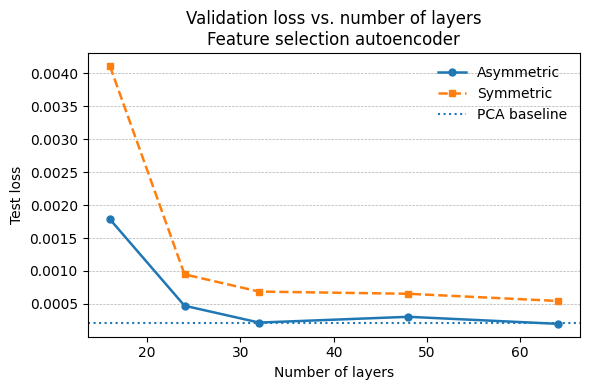

In [ ]:
fsae_asymmetric = hyperparameter_scores[
    hyperparameter_scores.index.str.contains("fsae/asymmetric")
]
fsae_symmetric = hyperparameter_scores[
    hyperparameter_scores.index.str.contains("fsae/symmetric")
]

fig, ax = plt.subplots(figsize=(6, 4))

fsae_asymmetric = fsae_asymmetric.sort_values("layers")
fsae_symmetric = fsae_symmetric.sort_values("layers")

ax.plot(
    fsae_asymmetric["layers"],
    fsae_asymmetric["test_loss"],
    label="Asymmetric",
    linestyle="-",
    marker="o",
    linewidth=1.8,
    markersize=5,
)

ax.plot(
    fsae_symmetric["layers"],
    fsae_symmetric["test_loss"],
    label="Symmetric",
    linestyle="--",
    marker="s",
    linewidth=1.8,
    markersize=5,
)

# PCA baseline
ax.axhline(
    y=combined_scores.loc["pca_v1", "test_loss"],
    linestyle=":",
    linewidth=1.5,
    label="PCA baseline",
)

ax.set_title("Validation loss vs. number of layers\nFeature selection autoencoder")
ax.set_xlabel("Number of layers")
ax.set_ylabel("Test loss")

ax.legend(frameon=False)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5)

fig.tight_layout()
plt.show()


In [ ]:
fsae_symmetric

,layers,symmetric_architecture,val_loss,test_loss,features_95_percentile,pixel_95_percentile,critical_wavelength_99_percentile
fsae/symmetric/16_v2,16.0,0.0,0.003757,0.004110,0.014645,0.011522,0.002438
fsae/symmetric/24_v1,24.0,0.0,0.000945,0.000948,0.002975,0.003498,0.001819
fsae/symmetric/32_v2,32.0,0.0,0.000692,0.000687,0.002846,0.002501,0.000768
fsae/symmetric/48_v1,48.0,0.0,0.000656,0.000654,0.002843,0.002279,0.000596
fsae/symmetric/64_v1,64.0,0.0,0.000549,0.000544,0.002533,0.001781,0.000366


In [ ]:
fsae_asymmetric

,layers,symmetric_architecture,val_loss,test_loss,features_95_percentile,pixel_95_percentile,critical_wavelength_99_percentile
fsae/asymmetric/16_v2,16.0,0.0,0.001446,0.001785,0.008770,0.003886,0.000577
fsae/asymmetric/24_v1,24.0,0.0,0.000479,0.000472,0.001581,0.001927,0.000562
fsae/asymmetric/32_v2,32.0,0.0,0.000222,0.000216,0.000629,0.000854,0.000221
fsae/asymmetric/48_v1,48.0,0.0,0.000305,0.000304,0.000971,0.001126,0.000179
fsae/asymmetric/64_v1,64.0,0.0,0.000200,0.000197,0.000629,0.000697,0.000078


# 3. Saturation Check

In [ ]:
s3 = boto3.client("s3")

response = s3.list_objects_v2(Bucket=saturation_results_bucket)
paths = {}

for obj in response.get("Contents", []):
    key = obj["Key"]
    match = re.match(r"([^/]+)/v(\d+)/score\.parquet$", key)
    if match:
        model, version = match.groups()
        version = int(version)
        if model not in paths or version > paths[model][0]:
            paths[model] = (version, key)

dfs = []
for model, (version, key) in paths.items():
    score_path = f"s3://{saturation_results_bucket}/{model}/v{version}/score.parquet"

    df = pd.read_parquet(score_path).T
    df.index = [f"{model}_v{version}"]
    dfs.append(df)

saturation_scores = pd.concat(dfs)
saturation_scores

,percentage,val_loss,test_loss,features_95_percentile,pixel_95_percentile,critical_wavelength_99_percentile
0.1_v2,0.1,0.005173,0.004810,0.014288,0.008469,0.002604
0.2_v1,0.2,0.003142,0.002628,0.009135,0.005549,0.001333
0.3_v2,0.3,0.002779,0.001638,0.005003,0.002854,0.000755
0.4_v1,0.4,0.002066,0.001624,0.006043,0.002206,0.000531
0.5_v2,0.5,0.001312,0.001328,0.005093,0.001084,0.000513
0.6_v1,0.6,0.001149,0.000797,0.001969,0.000786,0.000334
0.7_v2,0.7,0.000991,0.000929,0.003285,0.000419,0.000256
0.8_v1,0.8,0.000919,0.000858,0.003256,0.000437,0.000245
0.9_v2,0.9,0.000683,0.001008,0.003181,0.000451,0.000372
1_v2,1.0,0.000617,0.000901,0.003352,0.000325,0.000241


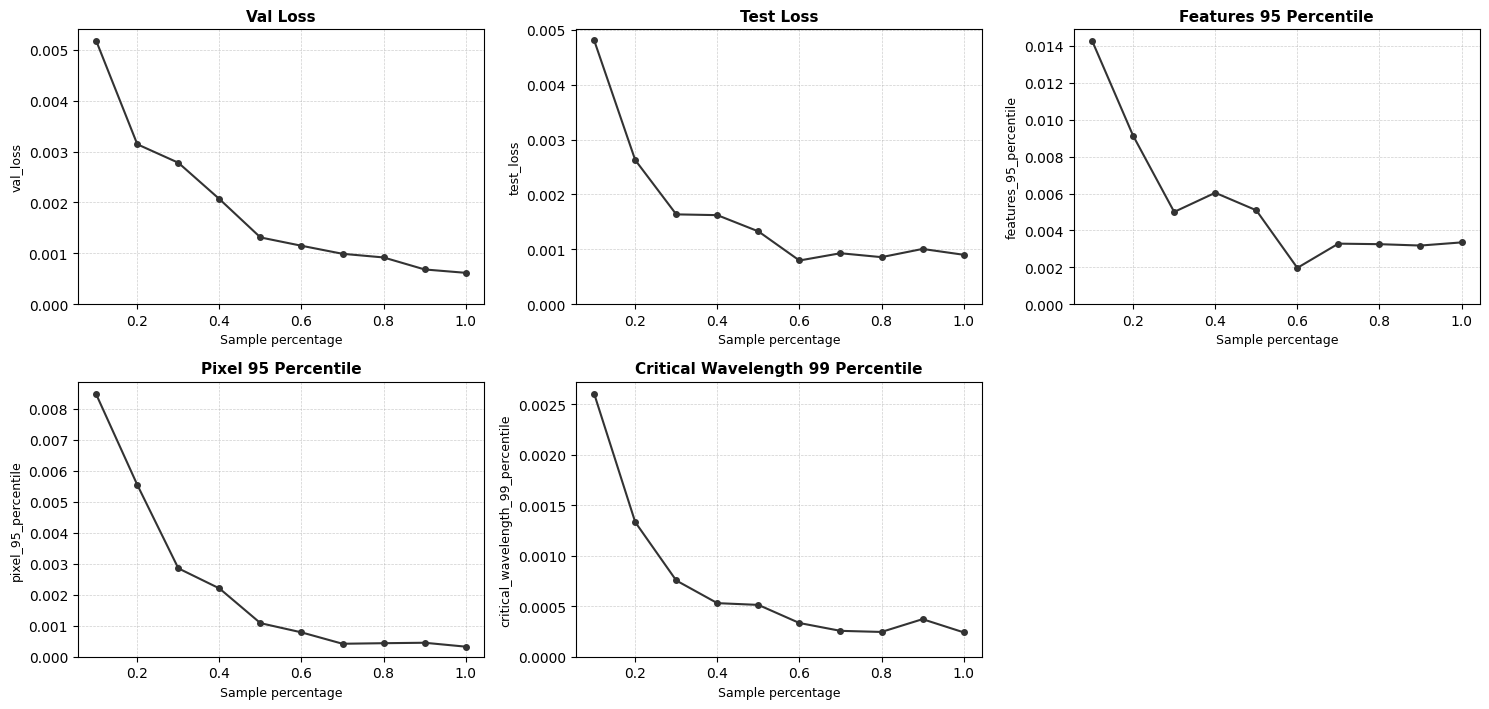

In [ ]:
metrics_cols = saturation_scores.columns.drop("percentage")

num_metrics = len(metrics_cols)
n_cols = 3
n_rows = (num_metrics + n_cols - 1) // n_cols

scores_sorted = saturation_scores.sort_values("percentage")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.6 * n_rows),
    squeeze=False
)

axes = axes.flatten()

for i, col in enumerate(metrics_cols):
    ax = axes[i]

    ax.plot(
        scores_sorted["percentage"],
        scores_sorted[col],
        marker="o",
        markersize=4,
        linestyle="-",
        linewidth=1.5,
        color="0.2",        
    )

    ax.set_title(col.replace("_", " ").title(), fontsize=11, weight="bold")
    ax.set_xlabel("Sample percentage", fontsize=9)
    ax.set_ylabel(col, fontsize=9)

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    ax.set_ylim(bottom=0)

    ax.margins(y=0.05)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
